<a href="https://colab.research.google.com/github/samarreguigui/summarization/blob/main/ERROR_~2_IPY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RQ2 - Error Injection: run FineSurE on the manually-injected summaries

This notebook reads the injected summaries you saved to Drive (one Excel per error type, under
`summarization/data/short_sum_with injected_Errors/<error type>/`) and runs FineSurE Task 1
(fact-checking) on them.

For every injection it answers three questions:

1. **Did the judge find it?** - is the single injected sentence flagged as an error (`label = 1`)?
2. **What type did it return?** - the FineSurE category the judge assigned to that sentence,
   compared with the planted type (the folder name).
3. **How did the change influence the summary in general?** - the overall faithfulness score of the
   injected summary vs the clean one (delta), plus *collateral* flags: other, untouched sentences
   that the judge started flagging only because of the injected error.

It reuses the same setup, Drive mount, cached OpenRouter client and FineSurE repo functions as the
RQ1 / verbosity run, so the judge model and parsing are identical.

## 1. Setup - install + clone (idempotent)

In [1]:
import importlib, subprocess, os, sys
PKGS = {'pymupdf':'fitz','tiktoken':'tiktoken','nltk':'nltk','pandas':'pandas',
        'tqdm':'tqdm','openai':'openai','httpx':'httpx','matplotlib':'matplotlib',
        'openpyxl':'openpyxl'}
for pip_name, import_name in PKGS.items():
    try: importlib.import_module(import_name)
    except ImportError:
        print('installing', pip_name); subprocess.check_call(['pip','-q','install','--upgrade',pip_name])
import nltk; nltk.download('punkt', quiet=True); nltk.download('punkt_tab', quiet=True)
if not os.path.isdir('/content/FineSurE-ACL24'):
    print('cloning FineSurE-ACL24...')
    subprocess.check_call(['git','clone','-q','https://github.com/DISL-Lab/FineSurE-ACL24.git'])
sys.path.insert(0,'/content/FineSurE-ACL24/finesure')
print('Setup done.')

installing pymupdf
cloning FineSurE-ACL24...
Setup done.


## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Configuration

`INJ_ROOT` points at the folder that holds one sub-folder per error type. Each sub-folder name **is**
the ground-truth FineSurE category, and each holds one `*.xlsx` keyed by summary name with the
injected sentence + the full injected summary. Empty error folders are simply skipped, so you can run
this now and re-run later once more folders are filled.

In [3]:
from pathlib import Path
PROJECT     = Path('/content/drive/MyDrive/summarization')
PAPER_DIR   = PROJECT / 'data' / 'paper'
INJ_ROOT    = PROJECT / 'data' / 'short_sum_with injected_Errors'
KEY_FILE    = Path('/content/drive/MyDrive/Master thesis/openrouter_key.txt')
# RQ1 (verbosity-bias) master scores, for the same-summary comparison:
RQ1_MASTER  = PROJECT / 'verbosity_bias_run' / 'results' / 'scores_master.csv'

WORK_DIR    = Path('/content/work_rq2_eval')
CACHE_DIR   = WORK_DIR / 'cache'
RESULTS_DIR = WORK_DIR / 'results'
FIGURES_DIR = WORK_DIR / 'figures'
for d in [WORK_DIR, CACHE_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL          = 'openai/gpt-4o-2024-05-13'   # same judge as RQ1
OPENROUTER_URL = 'https://openrouter.ai/api/v1'
TEMPERATURE    = 0.0

# Planted type -> FineSurE categories that count as a correct type call.
# Strict = the folder name itself; lenient adds near-equivalents.
LENIENT = {
    'entity error':         {'entity error'},
    'predicate error':      {'predicate error', 'linking error'},
    'circumstantial error': {'circumstantial error', 'entity error'},
    'coreference error':    {'coreference error'},
    'out-of-context error': {'out-of-context error', 'other error'},
    'grammatical error':    {'grammatical error'},
    'linking error':        {'linking error', 'predicate error'},
}
print('Injected-errors root:', INJ_ROOT)
print('Model:', MODEL)

Injected-errors root: /content/drive/MyDrive/summarization/data/short_sum_with injected_Errors
Model: openai/gpt-4o-2024-05-13


## 4. Helpers (same as RQ1)

In [4]:
import fitz, re, hashlib, json, time, ast, difflib
from typing import List
import tiktoken
from nltk.tokenize import sent_tokenize
ENC = tiktoken.get_encoding('cl100k_base')

def read_pdf(path):
    doc = fitz.open(path); t = '\n'.join(p.get_text() for p in doc); doc.close(); return t
def clean_article(raw):
    cut = re.split(r'\n\s*(References|REFERENCES|Bibliography)\b', raw, maxsplit=1)[0]
    cut = re.sub(r'[ \t]+',' ',cut); cut = re.sub(r'\n{3,}','\n\n',cut); return cut.strip()
def clean_summary(raw): return re.sub(r'\s+',' ',raw).strip()
def sentences_of(text): return [s.strip() for s in sent_tokenize(text) if s.strip()]
def find_article(paper_id):
    m = sorted(PAPER_DIR.glob(f'{paper_id}_*.pdf'))
    assert m, f'No article PDF for paper {paper_id} in {PAPER_DIR}'; return m[0]

def match_sentence_idx(sentences, target):
    ''' index of the sentence that best matches the injected sentence text. '''
    t = target.strip()
    for i,s in enumerate(sentences):
        if s.strip()==t: return i
    for i,s in enumerate(sentences):
        if t in s or s in t: return i
    sims = [difflib.SequenceMatcher(None, s, t).ratio() for s in sentences]
    return int(max(range(len(sentences)), key=lambda i: sims[i]))
print('Helpers ready.')

Helpers ready.


## 5. OpenRouter client + cached call (same cache format as RQ1)

In [5]:
import openai
API_KEY = KEY_FILE.read_text().strip()
client = openai.OpenAI(api_key=API_KEY, base_url=OPENROUTER_URL)
def _cache_key(model, prompt, temperature):
    h = hashlib.sha256(); h.update(model.encode()); h.update(b'|')
    h.update(str(temperature).encode()); h.update(b'|'); h.update(prompt.encode())
    return h.hexdigest()[:24]
def get_response(prompt, model=None, temperature=None, max_retries=3):
    model = model or MODEL; temperature = TEMPERATURE if temperature is None else temperature
    cf = CACHE_DIR / f'{_cache_key(model,prompt,temperature)}.json'
    if cf.exists(): return json.loads(cf.read_text())['response']
    last=None
    for a in range(max_retries):
        try:
            r = client.chat.completions.create(model=model,
                messages=[{'role':'user','content':prompt}], temperature=temperature)
            txt = r.choices[0].message.content
            cf.write_text(json.dumps({'model':model,'temperature':temperature,'prompt':prompt,'response':txt}))
            return txt
        except Exception as e:
            last=e; time.sleep(2**a)
    raise RuntimeError(f'Failed after {max_retries}: {last}')
print('Client ready. Cache:', CACHE_DIR)

Client ready. Cache: /content/work_rq2_eval/cache


## 6. Load the injected summaries from Drive

Reads every `*.xlsx` under each error-type sub-folder. The sub-folder name is the planted category.
Unreadable / truncated files are skipped, and duplicate (type, summary) rows are dropped, so a stray
half-written file won't corrupt the run.

In [6]:
import pandas as pd
EXPECTED_COLS = ['summary','original_sentence','injected_sentence','what_changed','full_injected_summary']

inj_rows = []
if not INJ_ROOT.exists():
    raise FileNotFoundError(f'{INJ_ROOT} not found - fix INJ_ROOT in the config cell.')
for folder in sorted(p for p in INJ_ROOT.iterdir() if p.is_dir()):
    etype = folder.name.strip()              # e.g. 'entity error'
    xlsx = sorted(folder.glob('*.xlsx'))
    if not xlsx:
        print(f'  (empty) {etype}'); continue
    for xf in xlsx:
        try:
            df = pd.read_excel(xf)
        except Exception as e:
            print(f'  skip unreadable {xf.name}: {e}'); continue
        df.columns = [str(c).strip() for c in df.columns]
        for _, r in df.iterrows():
            if pd.isna(r.get('full_injected_summary')): continue
            inj_rows.append({
                'error_type': etype,
                'summary': str(r['summary']).strip(),
                'paper_id': str(r['summary']).strip()[:2],
                'original_sentence': str(r.get('original_sentence','')).strip(),
                'injected_sentence': str(r['injected_sentence']).strip(),
                'what_changed': str(r.get('what_changed','')).strip(),
                'full_injected_summary': str(r['full_injected_summary']).strip(),
            })
inj = pd.DataFrame(inj_rows).drop_duplicates(['error_type','summary']).reset_index(drop=True)
print('Loaded injections:', len(inj))
print('By error type:'); print(inj['error_type'].value_counts().to_string())
inj.head()

  (empty) grammatical error
  (empty) linking error
  (empty) out-of-context error
  skip unreadable predicate_error__injections.xlsx: Error -3 while decompressing data: invalid literal/lengths set
Loaded injections: 24
By error type:
error_type
circumstantial error    8
coreference error       8
entity error            8


,error_type,summary,paper_id,original_sentence,injected_sentence,what_changed,full_injected_summary
0,circumstantial error,01_sum1_short,01,Importantly LLMs perform better on human gener...,Importantly LLMs perform better on human gener...,"Added false circumstantial condition ""only whe...",Background: The current trend towards evaluati...
1,circumstantial error,02_sum1_short,02,Environmental costs are significant - training...,Environmental costs are significant - training...,"Added false quantitative circumstance ""over 80...",Background: The starting point is the trend in...
2,circumstantial error,03_sum2_short,03,"on NPI illusions, the LMs and performed worse ...","on NPI illusions, the LMs and performed worse ...","Quantity ""other two types"" changed to ""other f...",Background: Humans tend to make errors during ...
3,circumstantial error,04_sum1_short,04,"Well, I learned that smell-based embeddings ca...","Well, I learned that smell-based embeddings ca...",Scope circumstance replaced with a contradicto...,Background: The starting point of the paper is...
4,circumstantial error,04_sum2_short,04,The study found that the best olfactory repres...,The study found that the best olfactory repres...,"Quantity ""30 dimensions"" changed to ""300 dimen...",Background: The authors question why the proce...


## 7. Clean baselines

For each distinct summary we need the **clean** short summary as the reference point (faithfulness and
which sentences the judge flags with no error planted). We reconstruct the clean summary from the
injected one by putting the original sentence back, so we don't depend on re-reading the source PDFs.

In [7]:
from utils import get_fact_checking_prompt, parsing_llm_fact_checking_output, compute_faithfulness_percentage_score

def judge(article, sents):
    raw = get_response(get_fact_checking_prompt(input=article, sentences=sents))
    pl, pt = parsing_llm_fact_checking_output(raw)
    return pl, pt, raw

# article text per paper (cached in memory)
_articles = {}
def article_for(pid):
    if pid not in _articles:
        _articles[pid] = clean_article(read_pdf(find_article(pid)))
    return _articles[pid]

# one clean summary per summary name: reconstruct by reverting the injected sentence
clean_text = {}
for _, r in inj.iterrows():
    name = r['summary']
    if name in clean_text: continue
    full = r['full_injected_summary']
    if r['original_sentence'] and r['injected_sentence'] in full:
        clean_text[name] = full.replace(r['injected_sentence'], r['original_sentence'])
    else:
        clean_text[name] = full   # fallback

clean_eval = {}
from tqdm.auto import tqdm
for name in tqdm(sorted(clean_text), desc='clean baselines'):
    pid = name[:2]; art = article_for(pid)
    sents = sentences_of(clean_text[name])
    cf = RESULTS_DIR / f'clean__{name}.json'
    if cf.exists():
        d = json.loads(cf.read_text())
    else:
        pl, pt, raw = judge(art, sents)
        d = {'sents':sents,'pred_labels':pl,'pred_types':pt}
        cf.write_text(json.dumps(d))
    clean_eval[name] = d
print('clean baselines:', len(clean_eval))

clean baselines:   0%|          | 0/8 [00:00<?, ?it/s]

clean baselines: 8


## 8. Run FineSurE on every injected summary + score the three questions

In [9]:
rows = []
for _, r in tqdm(list(inj.iterrows()), total=len(inj), desc='injected'):
    name, etype = r['summary'], r['error_type']
    pid = r['paper_id']; art = article_for(pid)
    sents = sentences_of(r['full_injected_summary'])
    idx = match_sentence_idx(sents, r['injected_sentence'])

    rf = RESULTS_DIR / f"inj__{etype.replace(' ','_')}__{name}.json"
    if rf.exists():
        d = json.loads(rf.read_text())
    else:
        pl, pt, raw = judge(art, sents)
        d = {'pred_labels':pl,'pred_types':pt}
        rf.write_text(json.dumps(d))
    pl, pt = d['pred_labels'], d['pred_types']
    if not pl or idx >= len(pl):
        print('  parse misalign:', etype, name); continue

    # Q1 + Q2: the injected sentence itself
    detected = int(pl[idx]==1)
    returned = pt[idx] if idx < len(pt) else None
    strict   = int(detected and returned == etype)
    lenient  = int(detected and returned in LENIENT.get(etype, {etype}))

    # Q3: general influence
    inj_faith = compute_faithfulness_percentage_score(pl)
    ce = clean_eval.get(name, {})
    cl = ce.get('pred_labels', [])
    clean_faith = compute_faithfulness_percentage_score(cl) if cl else None
    # collateral: untouched sentences newly flagged vs clean (aligned by index, same count)
    collateral = 0
    if cl and len(cl)==len(pl):
        for i in range(len(pl)):
            if i==idx: continue
            if pl[i]==1 and cl[i]==0: collateral += 1
    rows.append({
        'error_type':etype,'summary':name,'paper_id':pid,
        'injected_idx':idx,'n_sentences':len(sents),
        'detected':detected,'returned_category':returned,'expected_category':etype,
        'type_correct_strict':strict,'type_correct_lenient':lenient,
        'faithfulness_clean':clean_faith,'faithfulness_injected':inj_faith,
        'faithfulness_delta':(None if clean_faith is None else round(inj_faith-clean_faith,3)),
        'collateral_flags':collateral,
        'injected_sentence':r['injected_sentence'],'what_changed':r['what_changed'],
    })
res = pd.DataFrame(rows)
res.to_csv(RESULTS_DIR / 'injection_eval.csv', index=False)
print('scored:', len(res))
res.head(10)

injected:   0%|          | 0/24 [00:00<?, ?it/s]

  parse misalign: circumstantial error 04_sum2_short
  parse misalign: coreference error 04_sum2_short
  parse misalign: entity error 04_sum2_short
scored: 21


,error_type,summary,paper_id,injected_idx,n_sentences,detected,returned_category,expected_category,type_correct_strict,type_correct_lenient,faithfulness_clean,faithfulness_injected,faithfulness_delta,collateral_flags,injected_sentence,what_changed
0,circumstantial error,01_sum1_short,01,7,8,1,out-of-context error,circumstantial error,0,0,1.000000,0.875000,-0.125,0,Importantly LLMs perform better on human gener...,"Added false circumstantial condition ""only whe..."
1,circumstantial error,02_sum1_short,02,6,13,1,out-of-context error,circumstantial error,0,0,1.000000,0.909091,-0.091,0,Environmental costs are significant - training...,"Added false quantitative circumstance ""over 80..."
2,circumstantial error,03_sum2_short,03,7,11,1,grammatical error,circumstantial error,0,0,0.909091,0.818182,-0.091,1,"on NPI illusions, the LMs and performed worse ...","Quantity ""other two types"" changed to ""other f..."
3,circumstantial error,04_sum1_short,04,3,6,1,entity error,circumstantial error,0,1,1.000000,0.833333,-0.167,0,"Well, I learned that smell-based embeddings ca...",Scope circumstance replaced with a contradicto...
4,circumstantial error,05_sum1_short,05,0,5,1,out-of-context error,circumstantial error,0,0,0.375000,0.600000,0.225,0,Background: Language processing occurs in comp...,"Added false circumstantial restriction ""only i..."
5,circumstantial error,05_sum2_short,05,6,8,1,out-of-context error,circumstantial error,0,0,0.875000,0.750000,-0.125,0,While larger models generally align better wit...,"Quantity ""30 billion parameters"" changed to ""3..."
6,circumstantial error,06_sum_short,06,2,6,1,circumstantial error,circumstantial error,1,1,1.000000,0.833333,-0.167,0,This paper proposes a new benchmark (PlanBench...,"Added false date circumstance ""in 2019"" (not i..."
7,coreference error,01_sum1_short,01,5,8,0,no error,coreference error,0,0,1.000000,1.000000,0.000,0,No tested model is all around human-level-capa...,"Replaced ""some"" with singular pronoun ""it"" who..."
8,coreference error,02_sum1_short,02,10,13,0,no error,coreference error,0,0,1.000000,1.000000,0.000,0,Humans mistakenly interpret our coherent-seemi...,"Pronoun ""their"" (referring to LMs) changed to ..."
9,coreference error,03_sum2_short,03,8,11,0,no error,coreference error,0,0,0.909091,0.727273,-0.182,2,As LMs can not be seen as cognitive models of ...,"Pronoun ""they"" (referring to LMs) changed to ""..."


## 9. Q1 + Q2 - did the judge find it, and did it name the right type?

In [10]:
if len(res):
    print('Overall detection rate           : %.1f%%' % (100*res.detected.mean()))
    det = res[res.detected==1]
    if len(det):
        print('Type accuracy (strict)  | found : %.1f%%' % (100*det.type_correct_strict.mean()))
        print('Type accuracy (lenient) | found : %.1f%%' % (100*det.type_correct_lenient.mean()))
    print('\n-- detection rate by planted type --')
    print((res.groupby('error_type').detected.mean()*100).round(1).to_string())
    print('\n-- type accuracy (lenient, among found) by planted type --')
    print((det.groupby('error_type').type_correct_lenient.mean()*100).round(1).to_string())
    print('\n-- per-injection (found? / returned vs planted) --')
    show = res[['error_type','summary','detected','returned_category','expected_category','type_correct_lenient']]
    import pandas as pd
    with pd.option_context('display.max_rows',None,'display.max_colwidth',30):
        print(show.to_string(index=False))

Overall detection rate           : 66.7%
Type accuracy (strict)  | found : 35.7%
Type accuracy (lenient) | found : 42.9%

-- detection rate by planted type --
error_type
circumstantial error    100.0
coreference error         0.0
entity error            100.0

-- type accuracy (lenient, among found) by planted type --
error_type
circumstantial error    28.6
entity error            57.1

-- per-injection (found? / returned vs planted) --
          error_type       summary  detected    returned_category    expected_category  type_correct_lenient
circumstantial error 01_sum1_short         1 out-of-context error circumstantial error                     0
circumstantial error 02_sum1_short         1 out-of-context error circumstantial error                     0
circumstantial error 03_sum2_short         1    grammatical error circumstantial error                     0
circumstantial error 04_sum1_short         1         entity error circumstantial error                     1
circumstantial

## 10. Confusion matrix - planted type vs the category the judge returned

Rows = the error we planted; columns = what FineSurE called the injected sentence (`no error` = missed).

returned_category     no error  out-of-context error  entity error  predicate error  circumstantial error  grammatical error  coreference error  linking error  other error
error_type                                                                                                                                                                 
circumstantial error         0                     4             1                0                     1                  1                  0              0            0
coreference error            7                     0             0                0                     0                  0                  0              0            0
entity error                 0                     3             4                0                     0                  0                  0              0            0


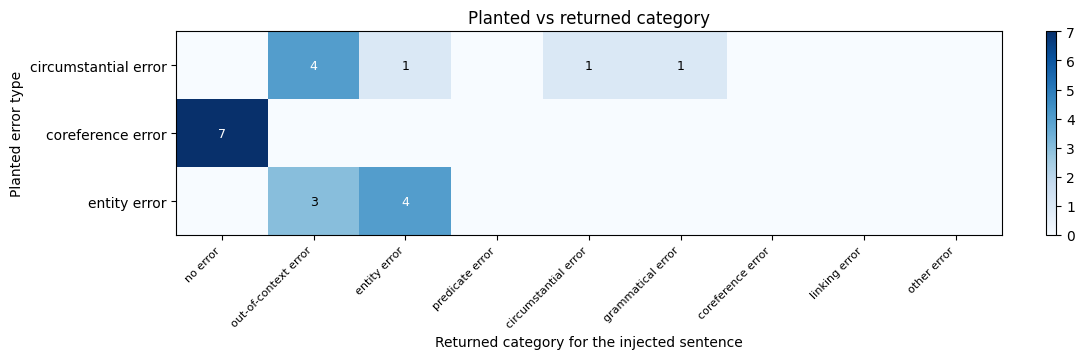

In [11]:
import numpy as np, matplotlib.pyplot as plt
if len(res):
    CATS = ['no error','out-of-context error','entity error','predicate error','circumstantial error',
            'grammatical error','coreference error','linking error','other error']
    cm = res.copy()
    cm['returned_category'] = cm['returned_category'].where(cm['detected']==1,'no error')
    types = sorted(res['error_type'].unique())
    conf = (cm.pivot_table(index='error_type', columns='returned_category', values='detected',
                           aggfunc='count', fill_value=0)
              .reindex(index=types).reindex(columns=CATS, fill_value=0))
    conf.to_csv(RESULTS_DIR / 'confusion_matrix.csv'); print(conf.to_string())
    fig, ax = plt.subplots(figsize=(11, 0.7*len(types)+1.6))
    im = ax.imshow(conf.values, aspect='auto', cmap='Blues')
    ax.set_xticks(range(len(CATS))); ax.set_xticklabels(CATS, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(types))); ax.set_yticklabels(types)
    for rI in range(conf.shape[0]):
        for cI in range(conf.shape[1]):
            v = conf.values[rI,cI]
            if v: ax.text(cI,rI,int(v),ha='center',va='center',
                          color='white' if v>conf.values.max()/2 else 'black', fontsize=9)
    ax.set_xlabel('Returned category for the injected sentence'); ax.set_ylabel('Planted error type')
    ax.set_title('Planted vs returned category')
    plt.colorbar(im, ax=ax, fraction=0.025); plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=120); plt.show()

## 11. Q3 - how the single change influenced the summary in general

Two effects per injection:
- **Faithfulness delta** = injected score - clean score. One planted error in an N-sentence summary
  should drop faithfulness by about `1/N` *if* the judge catches exactly that sentence; a larger drop
  means collateral damage, a zero drop means the judge missed it.
- **Collateral flags** = other, untouched sentences the judge began flagging only after the injection.

                      n  detect_rate  mean_faith_clean  mean_faith_injected  mean_faith_delta  mean_collateral
error_type                                                                                                    
circumstantial error  7        100.0              0.88                0.803            -0.077            0.143
coreference error     7          0.0              0.88                0.943             0.063            0.286
entity error          7        100.0              0.88                0.805            -0.075            0.000

Injections with collateral flagging (>=1 other sentence newly flagged): 2 / 21
Mean faithfulness drop overall: 0.030


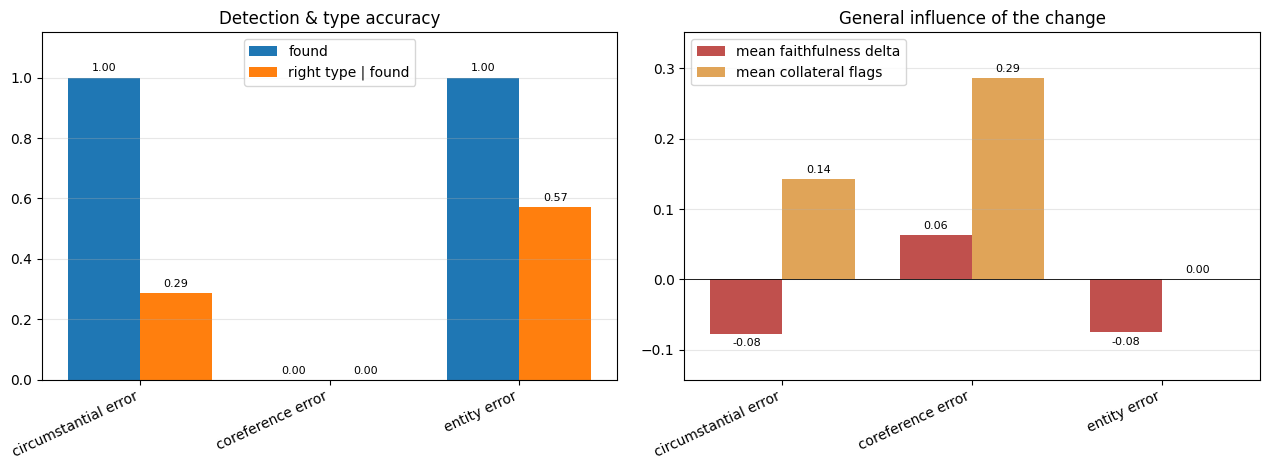

In [18]:
if len(res):
    g = res.groupby('error_type').agg(
        n=('summary','size'),
        detect_rate=('detected','mean'),
        mean_faith_clean=('faithfulness_clean','mean'),
        mean_faith_injected=('faithfulness_injected','mean'),
        mean_faith_delta=('faithfulness_delta','mean'),
        mean_collateral=('collateral_flags','mean'),
    ).round(3)
    g['detect_rate'] = (g['detect_rate']*100).round(1)
    print(g.to_string())
    print('\nInjections with collateral flagging (>=1 other sentence newly flagged): %d / %d'
          % ((res.collateral_flags>0).sum(), len(res)))
    print('Mean faithfulness drop overall: %.3f' % (-res.faithfulness_delta.dropna().mean()))

    import numpy as np, matplotlib.pyplot as plt
    def label_bars(ax, bars, fmt='{:.2f}'):
        for b in bars:
            h = b.get_height()
            if h is None or (isinstance(h, float) and np.isnan(h)): continue
            ax.annotate(fmt.format(h), (b.get_x()+b.get_width()/2, h),
                        ha='center', va='bottom' if h >= 0 else 'top',
                        xytext=(0, 3 if h >= 0 else -3), textcoords='offset points', fontsize=8)

    types = sorted(res.error_type.unique())
    x = np.arange(len(types)); w = 0.38
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    ax = axes[0]
    d = res.groupby('error_type').detected.mean().reindex(types)
    t = res[res.detected==1].groupby('error_type').type_correct_lenient.mean().reindex(types).fillna(0)
    label_bars(ax, ax.bar(x-w/2, d.values, w, label='found'))
    label_bars(ax, ax.bar(x+w/2, t.values, w, label='right type | found'))
    ax.set_xticks(x); ax.set_xticklabels(types, rotation=25, ha='right'); ax.set_ylim(0, 1.15)
    ax.set_title('Detection & type accuracy'); ax.legend(); ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    delta = res.groupby('error_type').faithfulness_delta.mean().reindex(types)
    coll  = res.groupby('error_type').collateral_flags.mean().reindex(types)
    label_bars(ax, ax.bar(x-w/2, delta.values, w, label='mean faithfulness delta', color='#c0504d'))
    label_bars(ax, ax.bar(x+w/2, coll.values,  w, label='mean collateral flags',  color='#e0a458'))
    ax.axhline(0, color='k', lw=0.6); ax.set_xticks(x); ax.set_xticklabels(types, rotation=25, ha='right')
    ax.set_title('General influence of the change'); ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.margins(y=0.18)

    plt.tight_layout(); fig.savefig(FIGURES_DIR / 'influence_summary.png', dpi=120); plt.show()

In [16]:
import re, ast
FOCUS_TYPE = 'coreference error'   # change to dig into any planted type

def extract_reasons(raw):
    raw = (raw or '').replace('```json', '').replace('```', '')
    m = re.search(r'\[.*\]', raw, flags=re.DOTALL)
    if not m:
        return []
    try:
        items = ast.literal_eval(m.group(0))
        return [str(it.get('reason', '')) for it in items if isinstance(it, dict)]
    except Exception:
        return []

sub = inj[inj['error_type'] == FOCUS_TYPE]
if not len(sub):
    print('No injections found for', FOCUS_TYPE)
else:
    for _, r in sub.iterrows():
        name, pid = r['summary'], r['paper_id']
        art = article_for(pid)
        isents = sentences_of(r['full_injected_summary'])
        idx = match_sentence_idx(isents, r['injected_sentence'])
        csents = sentences_of(clean_text[name])
        clp, clt, craw = judge(art, csents)      # cached
        ilp, ilt, iraw = judge(art, isents)      # cached
        crr, irr = extract_reasons(craw), extract_reasons(iraw)

        print('=' * 100)
        print(f'{name}   (injected sentence #{idx+1} of {len(isents)})')
        print('  change made :', r['what_changed'])
        print('  injected    :', isents[idx])
        det = (idx < len(ilp) and ilp[idx] == 1)
        print(f'  -> detected? {det}   returned: {ilt[idx] if idx < len(ilt) else None}')
        print(f'  -> judge reason for that sentence: {irr[idx] if idx < len(irr) else "(none)"}')

        print('  collateral (clean=ok -> injected=error):')
        n = min(len(clp), len(ilp)); any_c = False
        for i in range(n):
            if i == idx:
                continue
            if ilp[i] == 1 and clp[i] == 0:
                any_c = True
                print(f'     #{i+1} [{ilt[i] if i < len(ilt) else "?"}] {isents[i][:95]}')
                print(f'         reason: {irr[i] if i < len(irr) else ""}')
        if not any_c:
            print('     (none)')

        unf = [i+1 for i in range(n) if i != idx and clp[i] == 1 and ilp[i] == 0]
        if unf:
            print('  un-flagged (clean=error -> injected=ok) at sentences:', unf)

01_sum1_short   (injected sentence #6 of 8)
  change made : Replaced "some" with singular pronoun "it" whose antecedent ("No tested model") is wrong/contradictory.
  injected    : No tested model is all around human-level-capable, though it performs well on specific data sets / properties.
  -> detected? False   returned: no error
  -> judge reason for that sentence: This statement accurately reflects the finding that no model consistently matches human-level performance across all tasks, but some perform well on specific datasets or properties.
  collateral (clean=ok -> injected=error):
     (none)
02_sum1_short   (injected sentence #11 of 13)
  change made : Pronoun "their" (referring to LMs) changed to "our", creating a wrong antecedent (humans).
  injected    : Humans mistakenly interpret our coherent-seeming output as meaningful.
  -> detected? False   returned: no error
  -> judge reason for that sentence: This statement is consistent with the transcript, which discusses how huma

                      n  detect_rate  mean_faith_clean  mean_faith_injected  mean_faith_delta  mean_collateral
error_type                                                                                                    
circumstantial error  7        100.0              0.88                0.803            -0.077            0.143
coreference error     7          0.0              0.88                0.943             0.063            0.286
entity error          7        100.0              0.88                0.805            -0.075            0.000

Injections with collateral flagging (>=1 other sentence newly flagged): 2 / 21
Mean faithfulness drop overall: 0.030


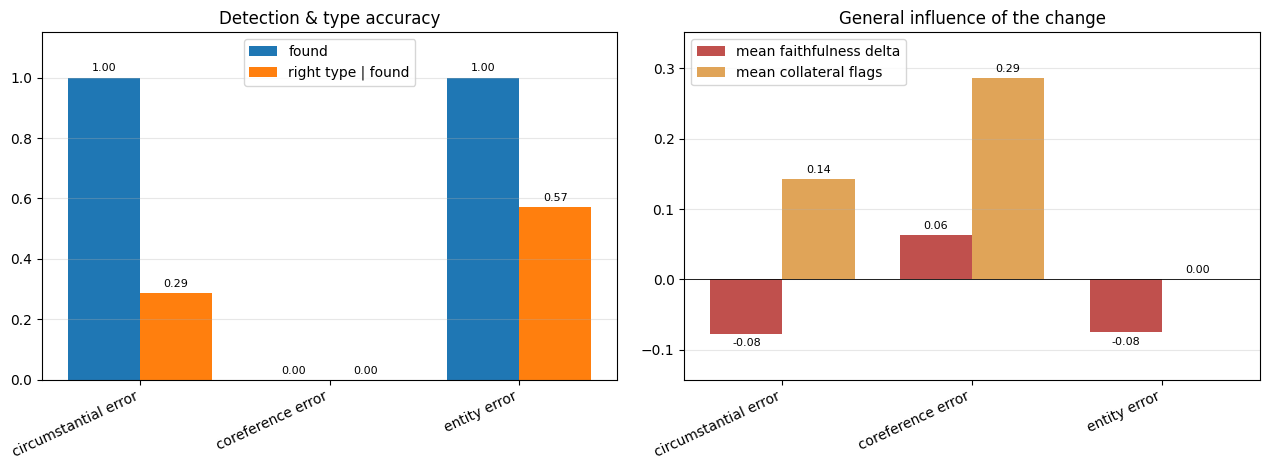

In [17]:
if len(res):
    g = res.groupby('error_type').agg(
        n=('summary','size'),
        detect_rate=('detected','mean'),
        mean_faith_clean=('faithfulness_clean','mean'),
        mean_faith_injected=('faithfulness_injected','mean'),
        mean_faith_delta=('faithfulness_delta','mean'),
        mean_collateral=('collateral_flags','mean'),
    ).round(3)
    g['detect_rate'] = (g['detect_rate']*100).round(1)
    print(g.to_string())
    print('\nInjections with collateral flagging (>=1 other sentence newly flagged): %d / %d'
          % ((res.collateral_flags>0).sum(), len(res)))
    print('Mean faithfulness drop overall: %.3f' % (-res.faithfulness_delta.dropna().mean()))

    import numpy as np, matplotlib.pyplot as plt
    def label_bars(ax, bars, fmt='{:.2f}'):
        for b in bars:
            h = b.get_height()
            if h is None or (isinstance(h, float) and np.isnan(h)): continue
            ax.annotate(fmt.format(h), (b.get_x()+b.get_width()/2, h),
                        ha='center', va='bottom' if h >= 0 else 'top',
                        xytext=(0, 3 if h >= 0 else -3), textcoords='offset points', fontsize=8)

    types = sorted(res.error_type.unique())
    x = np.arange(len(types)); w = 0.38
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    ax = axes[0]
    d = res.groupby('error_type').detected.mean().reindex(types)
    t = res[res.detected==1].groupby('error_type').type_correct_lenient.mean().reindex(types).fillna(0)
    label_bars(ax, ax.bar(x-w/2, d.values, w, label='found'))
    label_bars(ax, ax.bar(x+w/2, t.values, w, label='right type | found'))
    ax.set_xticks(x); ax.set_xticklabels(types, rotation=25, ha='right'); ax.set_ylim(0, 1.15)
    ax.set_title('Detection & type accuracy'); ax.legend(); ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    delta = res.groupby('error_type').faithfulness_delta.mean().reindex(types)
    coll  = res.groupby('error_type').collateral_flags.mean().reindex(types)
    label_bars(ax, ax.bar(x-w/2, delta.values, w, label='mean faithfulness delta', color='#c0504d'))
    label_bars(ax, ax.bar(x+w/2, coll.values,  w, label='mean collateral flags',  color='#e0a458'))
    ax.axhline(0, color='k', lw=0.6); ax.set_xticks(x); ax.set_xticklabels(types, rotation=25, ha='right')
    ax.set_title('General influence of the change'); ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.margins(y=0.18)

    plt.tight_layout(); fig.savefig(FIGURES_DIR / 'influence_summary.png', dpi=120); plt.show()

                      n  found  missed  right_type  collateral_sentences  summaries_with_collateral
error_type                                                                                         
circumstantial error  7      7       0           2                     1                          1
coreference error     7      0       7           0                     2                          1
entity error          7      7       0           4                     0                          0


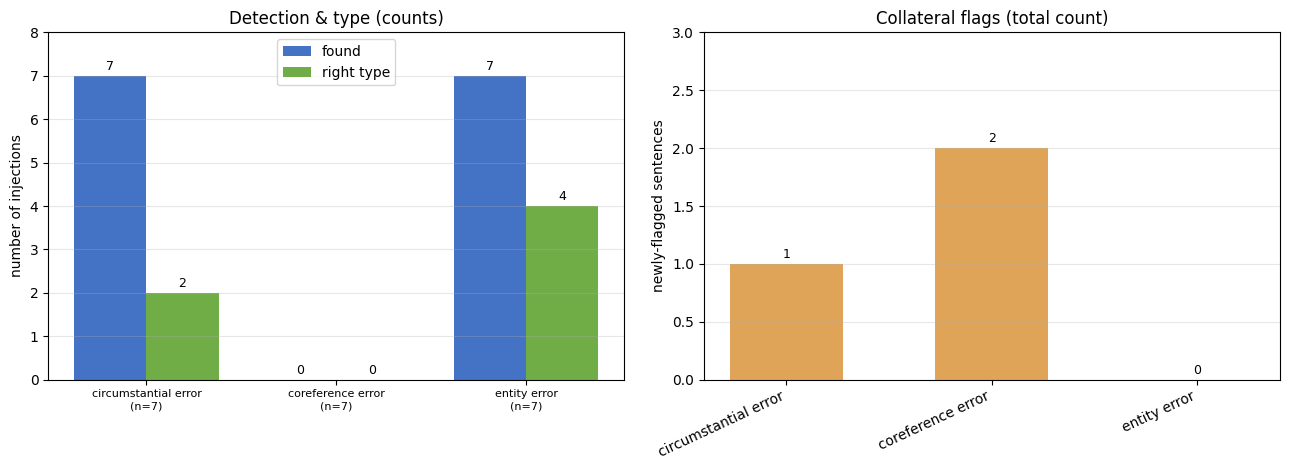

In [19]:
if len(res):
    import numpy as np, matplotlib.pyplot as plt

    types = sorted(res.error_type.unique())
    n      = res.groupby('error_type').size().reindex(types).fillna(0).astype(int)
    found  = res.groupby('error_type').detected.sum().reindex(types).fillna(0).astype(int)
    right  = (res[res.detected==1].groupby('error_type').type_correct_lenient.sum()
                 .reindex(types).fillna(0).astype(int))
    coll_total = res.groupby('error_type').collateral_flags.sum().reindex(types).fillna(0).astype(int)
    coll_summ  = (res.assign(c=res.collateral_flags>0).groupby('error_type').c.sum()
                     .reindex(types).fillna(0).astype(int))

    # counts table
    import pandas as pd
    tbl = pd.DataFrame({'n':n,'found':found,'missed':n-found,'right_type':right,
                        'collateral_sentences':coll_total,'summaries_with_collateral':coll_summ})
    print(tbl.to_string())

    def label_bars(ax, bars):
        for b in bars:
            h = b.get_height()
            ax.annotate(f'{int(h)}', (b.get_x()+b.get_width()/2, h),
                        ha='center', va='bottom', xytext=(0,2), textcoords='offset points', fontsize=9)

    x = np.arange(len(types)); w = 0.38
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    ax = axes[0]
    label_bars(ax, ax.bar(x-w/2, found.values, w, label='found',      color='#4472c4'))
    label_bars(ax, ax.bar(x+w/2, right.values, w, label='right type', color='#70ad47'))
    ax.set_xticks(x); ax.set_xticklabels([f'{t}\n(n={n[t]})' for t in types], fontsize=8)
    ax.set_ylim(0, int(n.max())+1); ax.set_ylabel('number of injections')
    ax.set_title('Detection & type (counts)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    label_bars(ax, ax.bar(x, coll_total.values, 0.55, color='#e0a458'))
    ax.set_xticks(x); ax.set_xticklabels(types, rotation=25, ha='right')
    ax.set_ylim(0, max(1, int(coll_total.max())+1)); ax.set_ylabel('newly-flagged sentences')
    ax.set_title('Collateral flags (total count)'); ax.grid(axis='y', alpha=0.3)

    plt.tight_layout(); fig.savefig(FIGURES_DIR / 'influence_counts.png', dpi=120); plt.show()

## 12. The misses - injected errors FineSurE did not flag

In [13]:
if len(res):
    miss = res[res.detected==0][['error_type','summary','injected_sentence','what_changed']]
    print('Missed: %d / %d' % (len(miss), len(res)))
    import pandas as pd
    with pd.option_context('display.max_rows',None,'display.max_colwidth',60):
        print(miss.to_string(index=False))

Missed: 7 / 21
       error_type       summary                                                                                                                                                                                                                                                                                                            injected_sentence                                                                                            what_changed
coreference error 01_sum1_short                                                                                                                                                                                                               No tested model is all around human-level-capable, though it performs well on specific data sets / properties. Replaced "some" with singular pronoun "it" whose antecedent ("No tested model") is wrong/contradictory.
coreference error 02_sum1_short                                                

## 13. Comparison with the verbosity-bias run (RQ1) - same short summaries

Your RQ1 run already scored these short summaries (clean). Here we line them up with this run:

- **Sanity check** - the clean baseline recomputed here should match RQ1's faithfulness for the same
  summary (mean abs diff near 0 confirms the judge + parsing are identical across the two notebooks).
- **Before/after** - RQ1 clean faithfulness vs the injected faithfulness per error type, so you can see
  how far each planted error pulls the score below the established baseline.

Set `RQ1_MASTER` in the config cell if your verbosity scores live elsewhere. Column names are detected
loosely (faithfulness / size / label).

Sanity: clean baseline vs RQ1 short faithfulness, mean abs diff = 0.097 (0 = identical)
Summaries where baseline != RQ1 (worth a look):
      summary  rq1_faithfulness  faithfulness_clean
03_sum2_short          0.727273            0.909091
05_sum1_short          0.875000            0.375000

-- faithfulness: RQ1 clean  ->  RQ2 injected, by summary x error type --
               RQ1_clean  circumstantial error  coreference error  entity error
summary                                                                        
01_sum1_short      1.000                 0.875              1.000         0.875
02_sum1_short      1.000                 0.909              1.000         0.923
03_sum2_short      0.727                 0.818              0.727         0.818
04_sum1_short      1.000                 0.833              1.000         0.833
05_sum1_short      0.875                 0.600              1.000         0.600
05_sum2_short      0.875                 0.750              0.875         

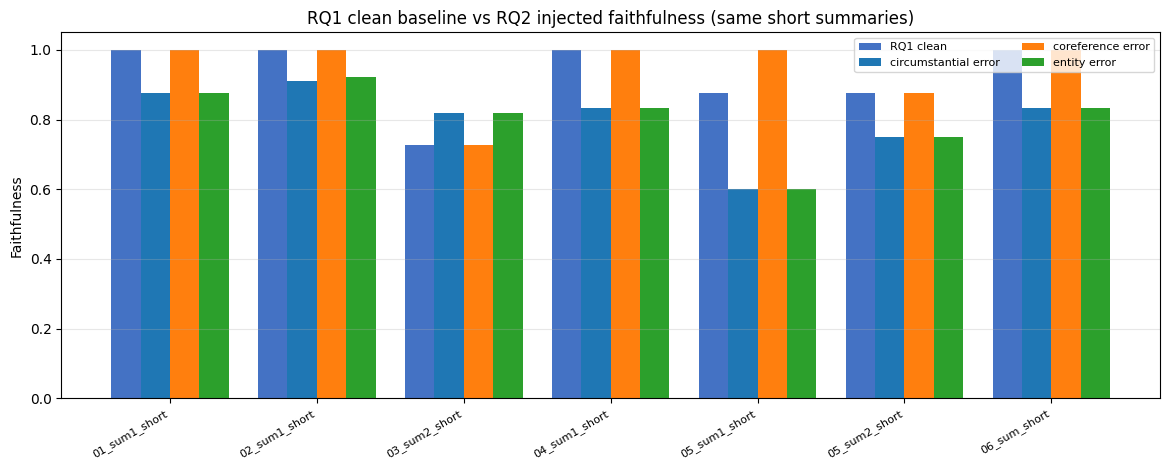

In [14]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
if not RQ1_MASTER.exists():
    print('RQ1 master CSV not found at', RQ1_MASTER)
    print('Point RQ1_MASTER at your verbosity-bias scores_master.csv to enable this comparison.')
elif not len(res):
    print('No RQ2 results to compare.')
else:
    rq1 = pd.read_csv(RQ1_MASTER)
    cols = {c.lower(): c for c in rq1.columns}
    label_col = cols.get('summary_label') or cols.get('label') or cols.get('summary')
    size_col, faith_col = cols.get('size'), cols.get('faithfulness')
    comp_col, conc_col  = cols.get('completeness'), cols.get('conciseness')
    rq1s = rq1.copy()
    if size_col is not None:
        rq1s = rq1s[rq1s[size_col].astype(str).str.lower().str.contains('short')]
    rq1s = rq1s.rename(columns={label_col:'summary', faith_col:'rq1_faithfulness'})
    keep = ['summary','rq1_faithfulness']
    if comp_col: rq1s = rq1s.rename(columns={comp_col:'rq1_completeness'}); keep.append('rq1_completeness')
    if conc_col: rq1s = rq1s.rename(columns={conc_col:'rq1_conciseness'}); keep.append('rq1_conciseness')
    rq1s = rq1s[keep].drop_duplicates('summary')

    cmp = res.merge(rq1s, on='summary', how='left')
    cmp['baseline_consistency'] = (cmp['faithfulness_clean'] - cmp['rq1_faithfulness']).round(3)
    cmp['injected_vs_rq1']      = (cmp['faithfulness_injected'] - cmp['rq1_faithfulness']).round(3)
    cmp.to_csv(RESULTS_DIR / 'comparison_vs_rq1.csv', index=False)

    bc = cmp['baseline_consistency'].dropna()
    if len(bc):
        print('Sanity: clean baseline vs RQ1 short faithfulness, mean abs diff = %.3f (0 = identical)' % bc.abs().mean())
        off = cmp[cmp['baseline_consistency'].abs() > 0.001][['summary','rq1_faithfulness','faithfulness_clean']].drop_duplicates()
        if len(off):
            print('Summaries where baseline != RQ1 (worth a look):'); print(off.to_string(index=False))

    base = cmp.groupby('summary')['rq1_faithfulness'].first().rename('RQ1_clean')
    piv  = cmp.pivot_table(index='summary', columns='error_type', values='faithfulness_injected')
    table = pd.concat([base, piv], axis=1).round(3)
    print('\n-- faithfulness: RQ1 clean  ->  RQ2 injected, by summary x error type --')
    print(table.to_string())
    print('\n-- mean drop below RQ1 baseline, by error type --')
    print((-cmp.groupby('error_type')['injected_vs_rq1'].mean()).round(3).to_string())

    types = sorted(cmp['error_type'].unique()); summaries = sorted(cmp['summary'].unique())
    x = np.arange(len(summaries)); w = 0.8/(len(types)+1)
    fig, ax = plt.subplots(figsize=(min(16, 2+1.4*len(summaries)), 4.8))
    ax.bar(x, base.reindex(summaries).values, w, label='RQ1 clean', color='#4472c4')
    for j,t in enumerate(types):
        ax.bar(x+(j+1)*w, piv[t].reindex(summaries).values, w, label=t)
    ax.set_xticks(x+0.4-w/2); ax.set_xticklabels(summaries, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0,1.05); ax.set_ylabel('Faithfulness')
    ax.set_title('RQ1 clean baseline vs RQ2 injected faithfulness (same short summaries)')
    ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); fig.savefig(FIGURES_DIR / 'compare_vs_rq1.png', dpi=120); plt.show()

## 14. Save results back to Drive

In [15]:
import shutil
dest = PROJECT / 'error_injection_eval_run'; dest.mkdir(parents=True, exist_ok=True)
for sub in ['results','figures']:
    s = WORK_DIR / sub; o = dest / sub
    if not s.exists(): continue
    if o.exists(): shutil.rmtree(o)
    shutil.copytree(s, o); print('copied', sub)
print('\nSaved to', dest)

copied results
copied figures

Saved to /content/drive/MyDrive/summarization/error_injection_eval_run


1. FineSurE detects content errors near‑perfectly, but is blind to reference errors.
Entity and circumstantial injections were caught 7/7 (100%) each. Coreference was caught 0/7 (0%). The deep dive shows why: the judge silently repairs the pronoun and scores the intended meaning ("our output" → reads it as "LM output… consistent with transcript"). Faithfulness is a sentence‑vs‑source check, and a pronoun swap introduces no fact that contradicts the article — so reference errors fall outside what the task can see. This is the cleanest result you have.
2. Detecting an error ≠ naming it correctly. Among the errors it did catch, type accuracy was only 35.7% strict / 42.9% lenient. The dominant failure is a default to "out‑of‑context error": 4/7 circumstantial and 3/7 entity injections were flagged but mislabeled as out‑of‑context, and circumstantial was almost never called circumstantial (1/7 exact). Takeaway: the binary error/no‑error signal is trustworthy; the 9‑way fine‑grained label is not reliable enough to use diagnostically.